### EDA — Medical Abstracts TC Corpus
Exploração do dataset bruto, mapeamento para classes de urgência e análise de distribuição para o projeto de triagem médica.

In [5]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

# O corpus de treino usa <label>\t<abstract>; o teste contém apenas o abstract.
def load_dat(path: Path) -> pd.DataFrame:
    """Carrega arquivos .dat rotulados ou não rotulados."""
    rows = []
    with open(path, encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t", 1)
            if len(parts) == 2:
                rows.append({"label": int(parts[0]), "text": parts[1]})
            else:
                rows.append({"text": line})
    return pd.DataFrame(rows)

train_df = load_dat(DATA_DIR / "train.dat")
test_df  = load_dat(DATA_DIR / "test.dat")

print(f"Train: {len(train_df):,} amostras | Test: {len(test_df):,} amostras")
print(f"\nColunas: {train_df.columns.tolist()}")
train_df.head(3)

Train: 14,438 amostras | Test: 14,442 amostras

Colunas: ['label', 'text']


,label,text
0,4,Catheterization laboratory events and hospital...
1,5,Renal abscess in children. Three cases of rena...
2,2,Hyperplastic polyps seen at sigmoidoscopy are ...


## Distribuição das classes originais
O corpus tem 5 classes numéricas:
| Label | Categoria |
|---|---|
| 1 | Neoplasms |
| 2 | Digestive system diseases |
| 3 | Nervous system diseases |
| 4 | Cardiovascular diseases |
| 5 | General pathological conditions |

category
General pathological conditions    4805
Neoplasms                          3163
Cardiovascular diseases            3051
Nervous system diseases            1925
Digestive system diseases          1494


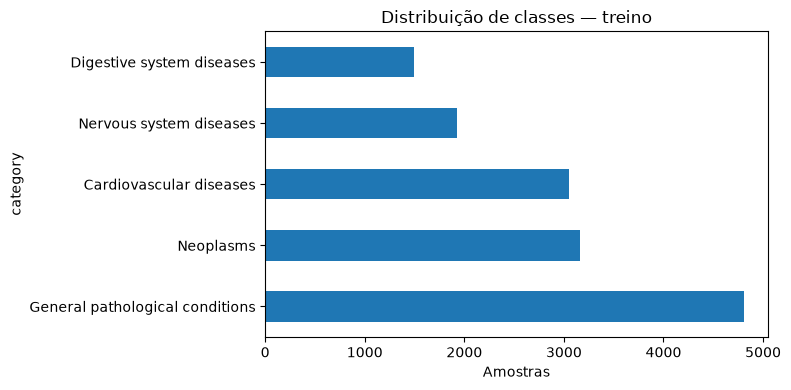

In [2]:
import matplotlib.pyplot as plt

LABEL_NAMES = {
    1: "Neoplasms",
    2: "Digestive system diseases",
    3: "Nervous system diseases",
    4: "Cardiovascular diseases",
    5: "General pathological conditions",
}

train_df["category"] = train_df["label"].map(LABEL_NAMES)
counts = train_df["category"].value_counts()
print(counts.to_string())

counts.plot(kind="barh", figsize=(8, 4), title="Distribuição de classes — treino")
plt.xlabel("Amostras")
plt.tight_layout()
plt.show()


### Mapeamento para urgência
Regra clínica justificada para mapear as 5 categorias nas 3 classes do projeto:
| Categoria original | Urgência | Justificativa |
|---|---|---|
| Neoplasms | urgente | Diagnóstico oncológico requer ação imediata |
| Cardiovascular diseases | urgente | Risco de vida iminente |
| Nervous system diseases | atencao | Monitoramento especializado necessário |
| Digestive system diseases | atencao | Avaliação clínica em 24–48h |
| General pathological conditions | normal | Condições gerais sem urgência imediata |

=== Distribuição de urgência — treino ===
urgency
urgente    6214
normal     4805
atencao    3419

Total treino: 14,438 | Total teste: 14,442


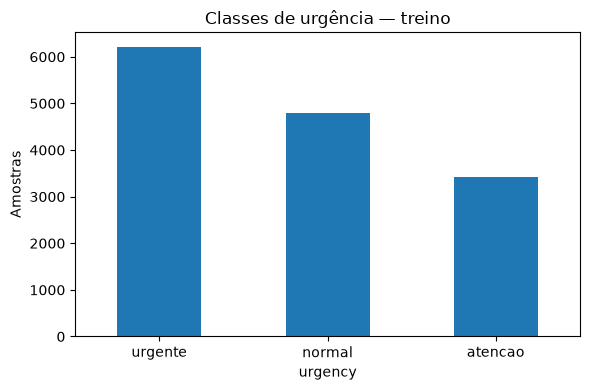

In [7]:
URGENCY_MAP = {
    1: "urgente",   # Neoplasms
    2: "atencao",   # Digestive system diseases
    3: "atencao",   # Nervous system diseases
    4: "urgente",   # Cardiovascular diseases
    5: "normal",    # General pathological conditions
}

train_df["urgency"] = train_df["label"].map(URGENCY_MAP)

print("=== Distribuição de urgência — treino ===")
urgency_counts = train_df["urgency"].value_counts()
print(urgency_counts.to_string())
print(f"\nTotal treino: {len(train_df):,} | Total teste: {len(test_df):,}")

urgency_counts.plot(kind="bar", figsize=(6, 4), title="Classes de urgência — treino", rot=0)
plt.ylabel("Amostras")
plt.tight_layout()
plt.show()

#### Análise do texto
Verificação de comprimento dos abstracts e qualidade básica dos dados.

In [8]:
train_df["text_len"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

print("=== Comprimento dos textos (caracteres) ===")
print(train_df["text_len"].describe().round(1).to_string())

print("\n=== Contagem de palavras ===")
print(train_df["word_count"].describe().round(1).to_string())

print(f"\nTextos nulos: {train_df['text'].isna().sum()}")
print(f"Textos duplicados: {train_df['text'].duplicated().sum()}")


=== Comprimento dos textos (caracteres) ===
count    14438.0
mean      1229.7
std        507.3
min        169.0
25%        849.0
50%       1209.0
75%       1588.0
max       3998.0

=== Contagem de palavras ===
count    14438.0
mean       179.9
std         76.5
min         24.0
25%        122.0
50%        176.0
75%        235.0
max        596.0

Textos nulos: 0
Textos duplicados: 3211


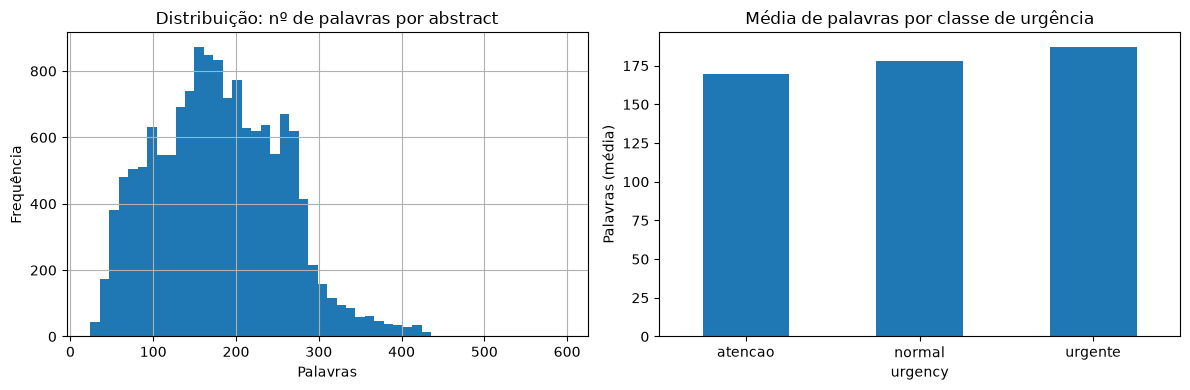

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df["word_count"].hist(bins=50, ax=axes[0])
axes[0].set_title("Distribuição: nº de palavras por abstract")
axes[0].set_xlabel("Palavras")
axes[0].set_ylabel("Frequência")

train_df.groupby("urgency")["word_count"].mean().plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Média de palavras por classe de urgência")
axes[1].set_ylabel("Palavras (média)")

plt.tight_layout()
plt.show()


### Exemplo de abstract por classe
Verificação qualitativa dos textos.

In [10]:
for urgency in ["normal", "atencao", "urgente"]:
    sample = train_df[train_df["urgency"] == urgency]["text"].iloc[0]
    print(f"[{urgency.upper()}]\n{sample[:300]}\n{'─'*60}\n")


[NORMAL]
Renal abscess in children. Three cases of renal abscesses in children are described to illustrate the variable presenting features. An additional 23 pediatric cases, reported over the past ten years, were reviewed for clinical features and therapy. Fever, loin pain, and leukocytosis were common pres
────────────────────────────────────────────────────────────

[ATENCAO]
Hyperplastic polyps seen at sigmoidoscopy are markers for additional adenomas seen at colonoscopy. Asymptomatic individuals undergoing screening flexible sigmoidoscopy were prospectively studied. Polyps were found in 185 subjects. The endoscopist recorded an opinion on the polyps' histology based on
────────────────────────────────────────────────────────────

[URGENTE]
Catheterization laboratory events and hospital outcome with direct angioplasty for acute myocardial infarction To assess the safety of direct infarct angioplasty without antecedent thrombolytic therapy, catheterization laboratory and hospital ev

### Salvar dataset processado
Gera `data/processed/train.csv` e `data/processed/test.csv` com as colunas `text` e `urgency` prontas para o pipeline de treino.

In [13]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_df[["text", "urgency"]].to_csv(PROCESSED_DIR / "train.csv", index=False)
test_df[["text"]].to_csv(PROCESSED_DIR / "test.csv", index=False)

print(f"Salvo em {PROCESSED_DIR.resolve()}")
print(f"  train.csv: {len(train_df):,} linhas")
print(f"  test.csv:  {len(test_df):,} linhas")

Salvo em C:\Users\efralmeida\OneDrive - Sefaz-SP\Documentos\Eduardo\Pessoal\Cursos\FIAP ML\Tech Challenge 03\tc3-medtriage\data\processed
  train.csv: 14,438 linhas
  test.csv:  14,442 linhas
